In [9]:
import pandas as pd
import matplotlib.pyplot as plt

nav_df = pd.read_csv("../data/cleaned/clean_nav.csv")

nav_df.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [10]:
print("Shape:", nav_df.shape)
print("\nColumns:")
print(nav_df.columns)

print("\nDate range:")
print(nav_df["date"].min(), "to", nav_df["date"].max())

print("\nNumber of schemes:")
print(nav_df["amfi_code"].nunique())

Shape: (46000, 3)

Columns:
Index(['amfi_code', 'date', 'nav'], dtype='str')

Date range:
2022-01-03 to 2026-05-29

Number of schemes:
40


In [11]:
print("Date range:")
print(nav_df["date"].min(), "to", nav_df["date"].max())

print("\nMissing values:")
print(nav_df.isnull().sum())

print("\nDuplicate rows:")
print(nav_df.duplicated().sum())

Date range:
2022-01-03 to 2026-05-29

Missing values:
amfi_code    0
date         0
nav          0
dtype: int64

Duplicate rows:
0


In [12]:
nav_df["date"] = pd.to_datetime(nav_df["date"])

print(nav_df.dtypes)

amfi_code             int64
date         datetime64[us]
nav                 float64
dtype: object


In [13]:
nav_df = nav_df.sort_values(["amfi_code", "date"]).reset_index(drop=True)

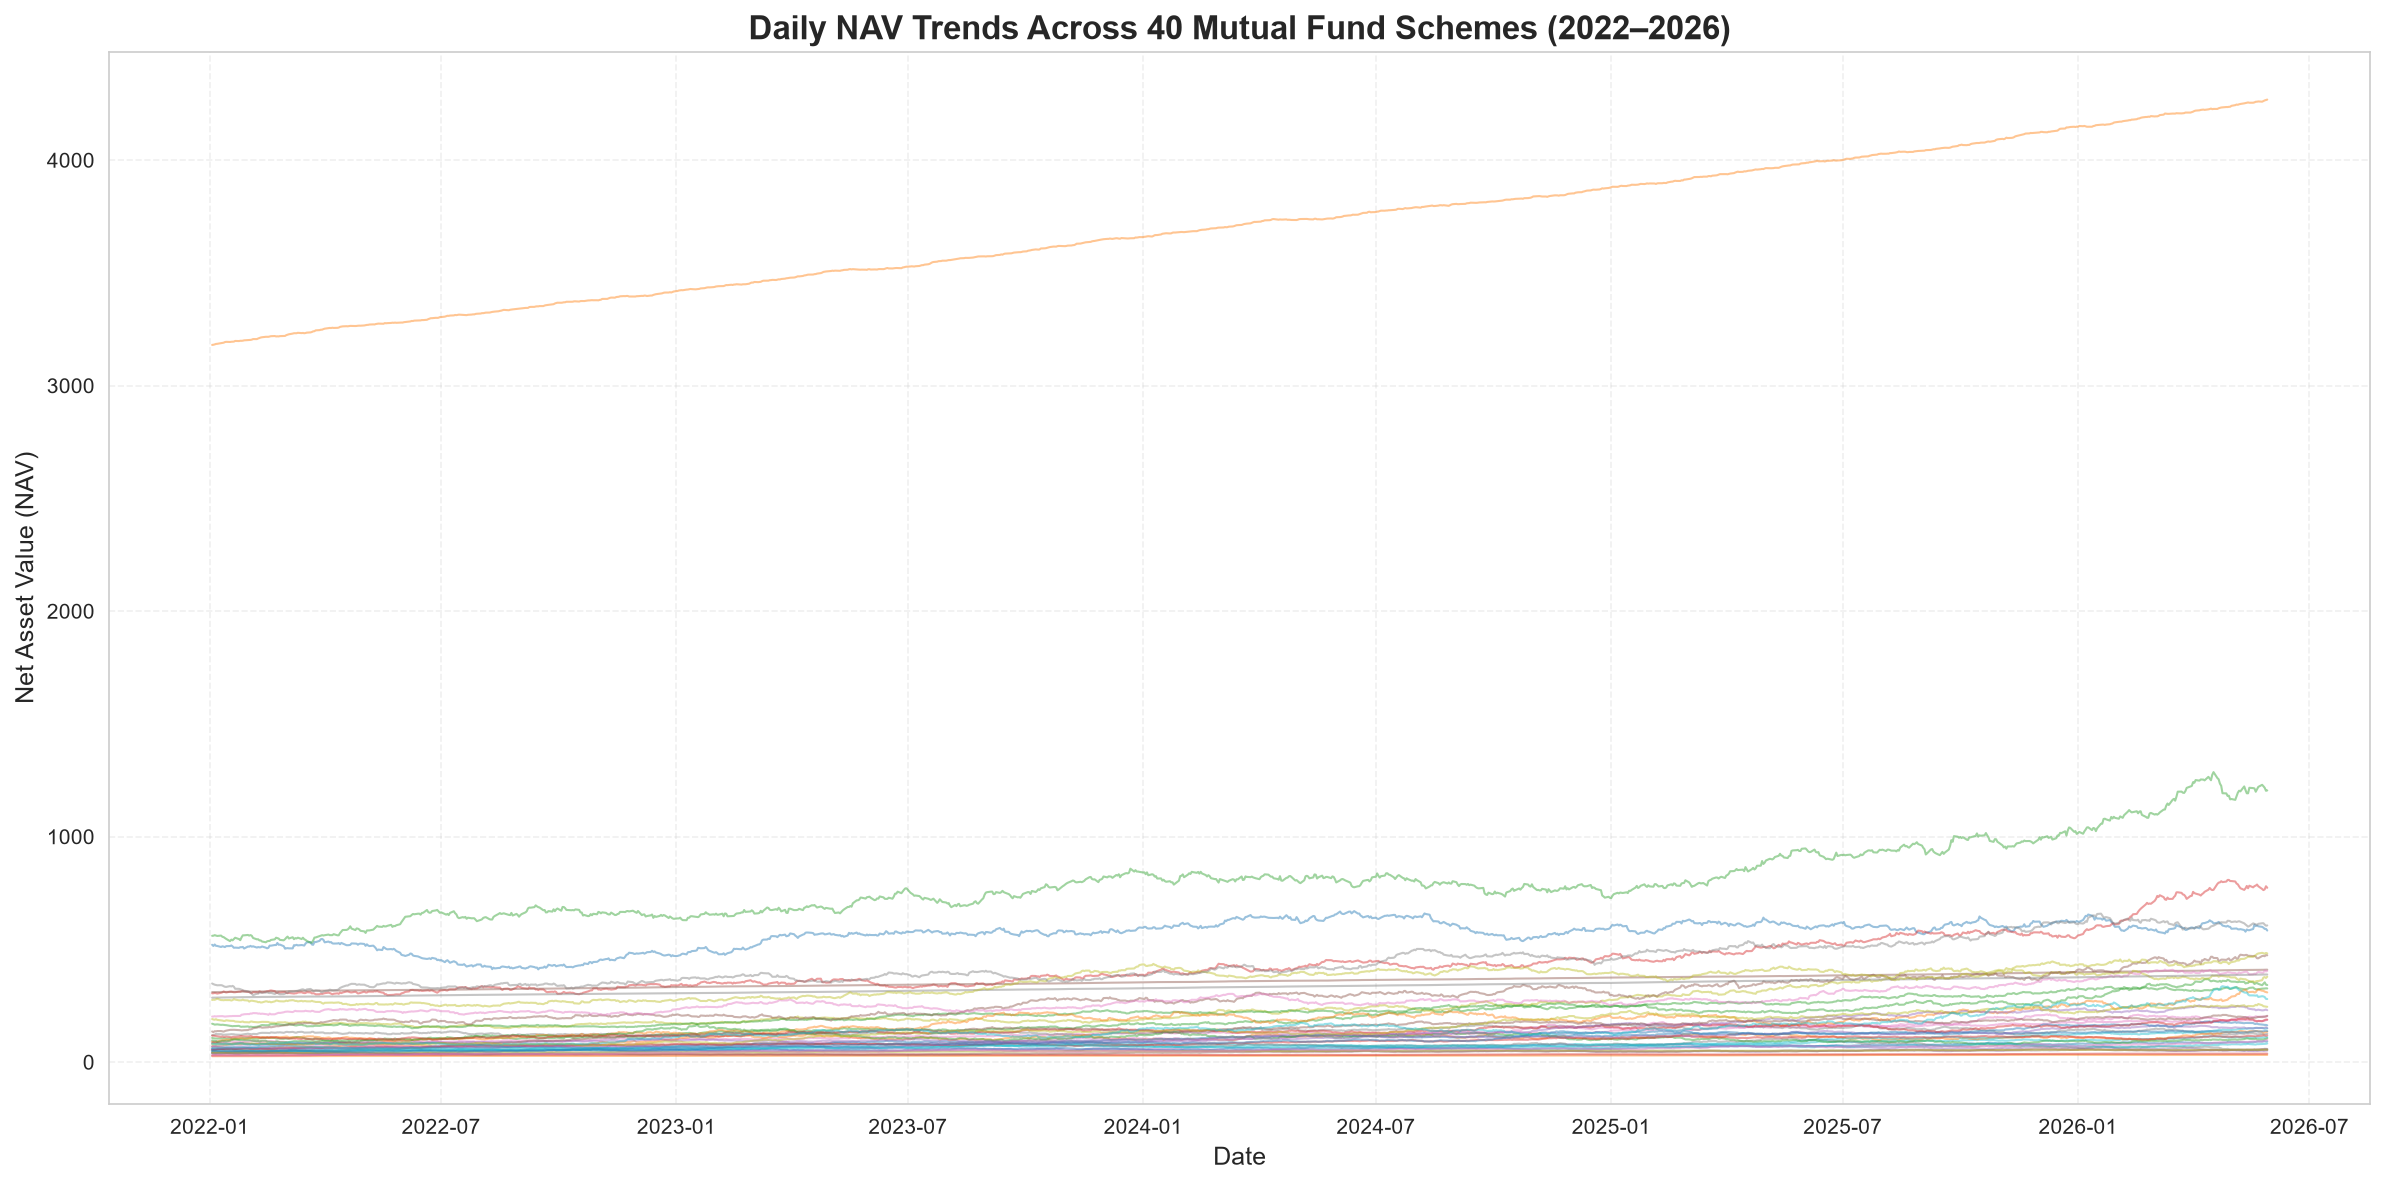

In [14]:
plt.figure(figsize=(16, 8), dpi=150)

for code in nav_df["amfi_code"].unique():
    temp = nav_df[nav_df["amfi_code"] == code]

    plt.plot(
        temp["date"],
        temp["nav"],
        linewidth=1,
        alpha=0.45
    )

plt.title(
    "Daily NAV Trends Across 40 Mutual Fund Schemes (2022–2026)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Date", fontsize=12)
plt.ylabel("Net Asset Value (NAV)", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:

avg_nav = (
    nav_df.groupby("date")["nav"]
    .mean()
    .reset_index()
)

avg_nav.head()

,date,nav
0,2022-01-03,207.213793
1,2022-01-04,206.890585
2,2022-01-05,207.226548
3,2022-01-06,207.190405
4,2022-01-07,207.081100


In [16]:
print("Date range:", avg_nav["date"].min(), "to", avg_nav["date"].max())
print("Number of dates:", len(avg_nav))

Date range: 2022-01-03 00:00:00 to 2026-05-29 00:00:00
Number of dates: 1150


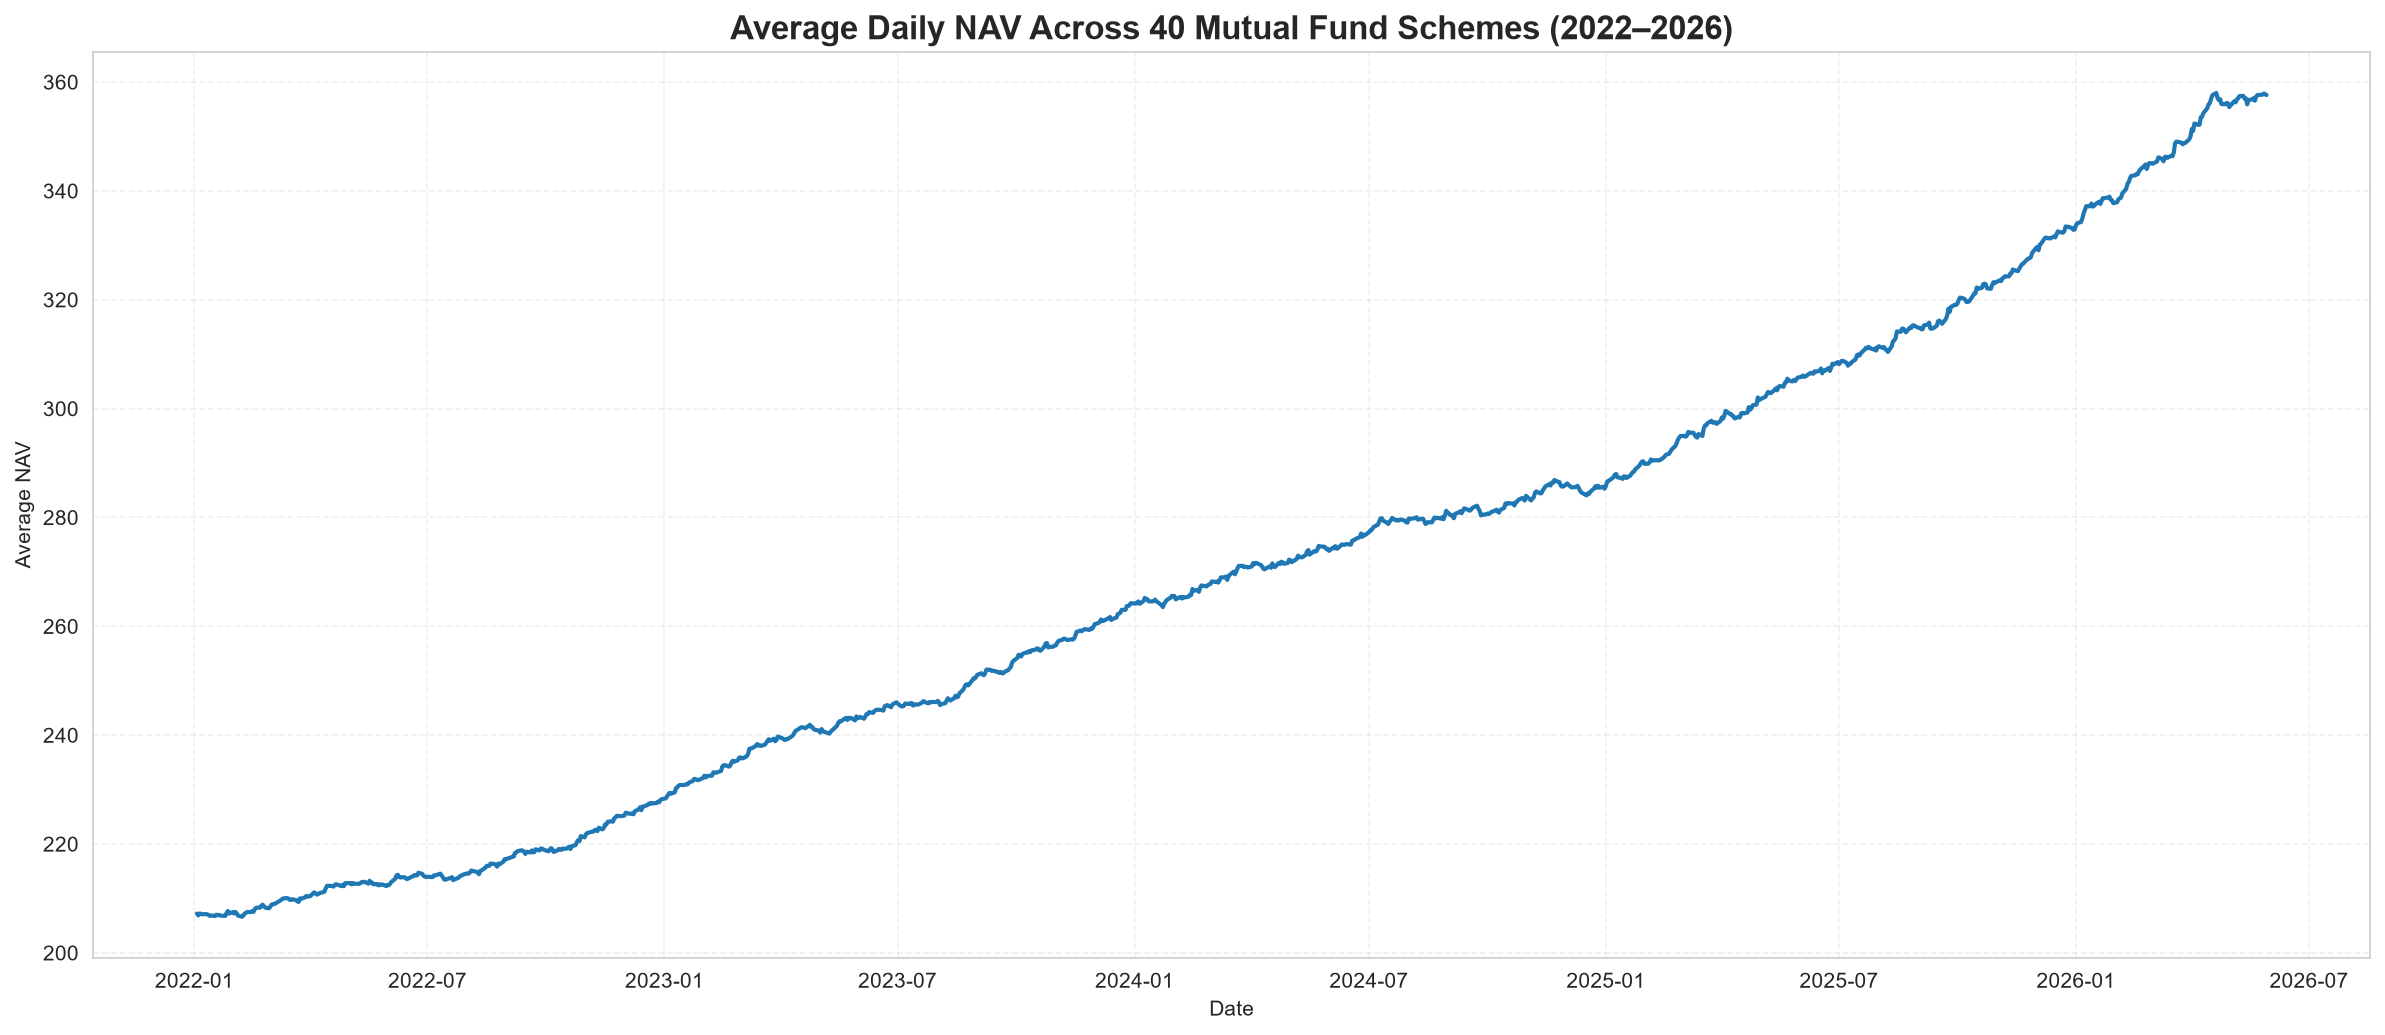

In [17]:
plt.figure(figsize=(16, 7), dpi=150)

plt.plot(
    avg_nav["date"],
    avg_nav["nav"],
    linewidth=2
)

plt.title(
    "Average Daily NAV Across 40 Mutual Fund Schemes (2022–2026)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Average NAV")

plt.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:

monthly_nav = (
    nav_df
    .set_index("date")
    .resample("ME")["nav"]
    .mean()
    .reset_index()
)

monthly_nav["pct_change"] = monthly_nav["nav"].pct_change() * 100

monthly_nav.tail(10)

,date,nav,pct_change
43,2025-08-31,313.180407,1.115204
44,2025-09-30,316.132001,0.942458
45,2025-10-31,321.449971,1.682199
46,2025-11-30,325.681151,1.316280
47,2025-12-31,331.733029,1.858222
48,2026-01-31,337.117471,1.623125
49,2026-02-28,342.076357,1.470967
50,2026-03-31,347.187520,1.494159
51,2026-04-30,355.025381,2.257530
52,2026-05-31,357.039198,0.567232


In [19]:
monthly_nav.sort_values("pct_change").head(10)

,date,nav,pct_change
35,2024-12-31,285.272562,0.010144
6,2022-07-31,213.956111,0.044536
31,2024-08-31,279.736082,0.255169
1,2022-02-28,207.717759,0.316990
33,2024-10-31,282.127765,0.395280
4,2022-05-31,212.731451,0.423915
32,2024-09-30,281.016961,0.457888
9,2022-10-31,219.529633,0.473846
18,2023-07-31,245.780681,0.480459
5,2022-06-30,213.860867,0.530912


In [20]:
monthly_nav.sort_values("pct_change", ascending=False).head(10)

,date,nav,pct_change
51,2026-04-30,355.025381,2.257530
47,2025-12-31,331.733029,1.858222
10,2022-11-30,223.470692,1.795229
14,2023-03-31,238.009623,1.779769
12,2023-01-31,230.671234,1.724551
45,2025-10-31,321.449971,1.682199
20,2023-09-30,251.833677,1.654622
48,2026-01-31,337.117471,1.623125
38,2025-03-31,296.158074,1.512792
40,2025-05-31,303.939743,1.511884


In [21]:
monthly_nav[
    monthly_nav["date"].dt.year == 2024
][["date", "nav", "pct_change"]]

,date,nav,pct_change
24,2024-01-31,264.620575,0.992385
25,2024-02-29,266.331713,0.646639
26,2024-03-31,269.597812,1.226328
27,2024-04-30,271.300039,0.631395
28,2024-05-31,273.450521,0.792658
29,2024-06-30,275.465499,0.736871
30,2024-07-31,279.024099,1.291850
31,2024-08-31,279.736082,0.255169
32,2024-09-30,281.016961,0.457888
33,2024-10-31,282.127765,0.395280


In [22]:
monthly_nav[
    (monthly_nav["date"].dt.year == 2024) &
    (monthly_nav["pct_change"] < 0)
][["date", "nav", "pct_change"]]

,date,nav,pct_change


In [23]:
monthly_nav[
    monthly_nav["date"].dt.year == 2024
][["date", "nav", "pct_change"]].to_string(index=False)

'      date        nav  pct_change\n2024-01-31 264.620575    0.992385\n2024-02-29 266.331713    0.646639\n2024-03-31 269.597812    1.226328\n2024-04-30 271.300039    0.631395\n2024-05-31 273.450521    0.792658\n2024-06-30 275.465499    0.736871\n2024-07-31 279.024099    1.291850\n2024-08-31 279.736082    0.255169\n2024-09-30 281.016961    0.457888\n2024-10-31 282.127765    0.395280\n2024-11-30 285.243625    1.104415\n2024-12-31 285.272562    0.010144'

In [24]:
monthly_nav[
    (monthly_nav["date"].dt.year == 2024) &
    (monthly_nav["pct_change"] < 0)
][["date", "nav", "pct_change"]].to_string(index=False)

'Empty DataFrame\nColumns: [date, nav, pct_change]\nIndex: []'

In [ ]:

scheme_monthly = (
    nav_df
    .set_index("date")
    .groupby("amfi_code")["nav"]
    .resample("ME")
    .mean()
    .reset_index()
)

scheme_monthly["pct_change"] = (
    scheme_monthly
    .groupby("amfi_code")["nav"]
    .pct_change() * 100
)


corrections_2024 = (
    scheme_monthly[
        (scheme_monthly["date"].dt.year == 2024) &
        (scheme_monthly["pct_change"] < 0)
    ]
    .sort_values("pct_change")
)

corrections_2024.head(10)

,amfi_code,date,nav,pct_change
1201,119599,2024-12-31,101.097973,-12.329879
2098,149324,2024-08-31,140.765555,-10.374886
1146,119598,2024-10-31,195.103378,-9.240202
1140,119598,2024-04-30,181.896373,-9.048723
1406,120506,2024-05-31,263.330770,-8.961181
554,118633,2024-01-31,53.479670,-8.156027
32,100016,2024-09-30,583.044210,-7.488779
1192,119599,2024-03-31,110.471938,-7.392939
247,101207,2024-12-31,71.959700,-6.860434
936,119095,2024-12-31,75.382436,-6.802272


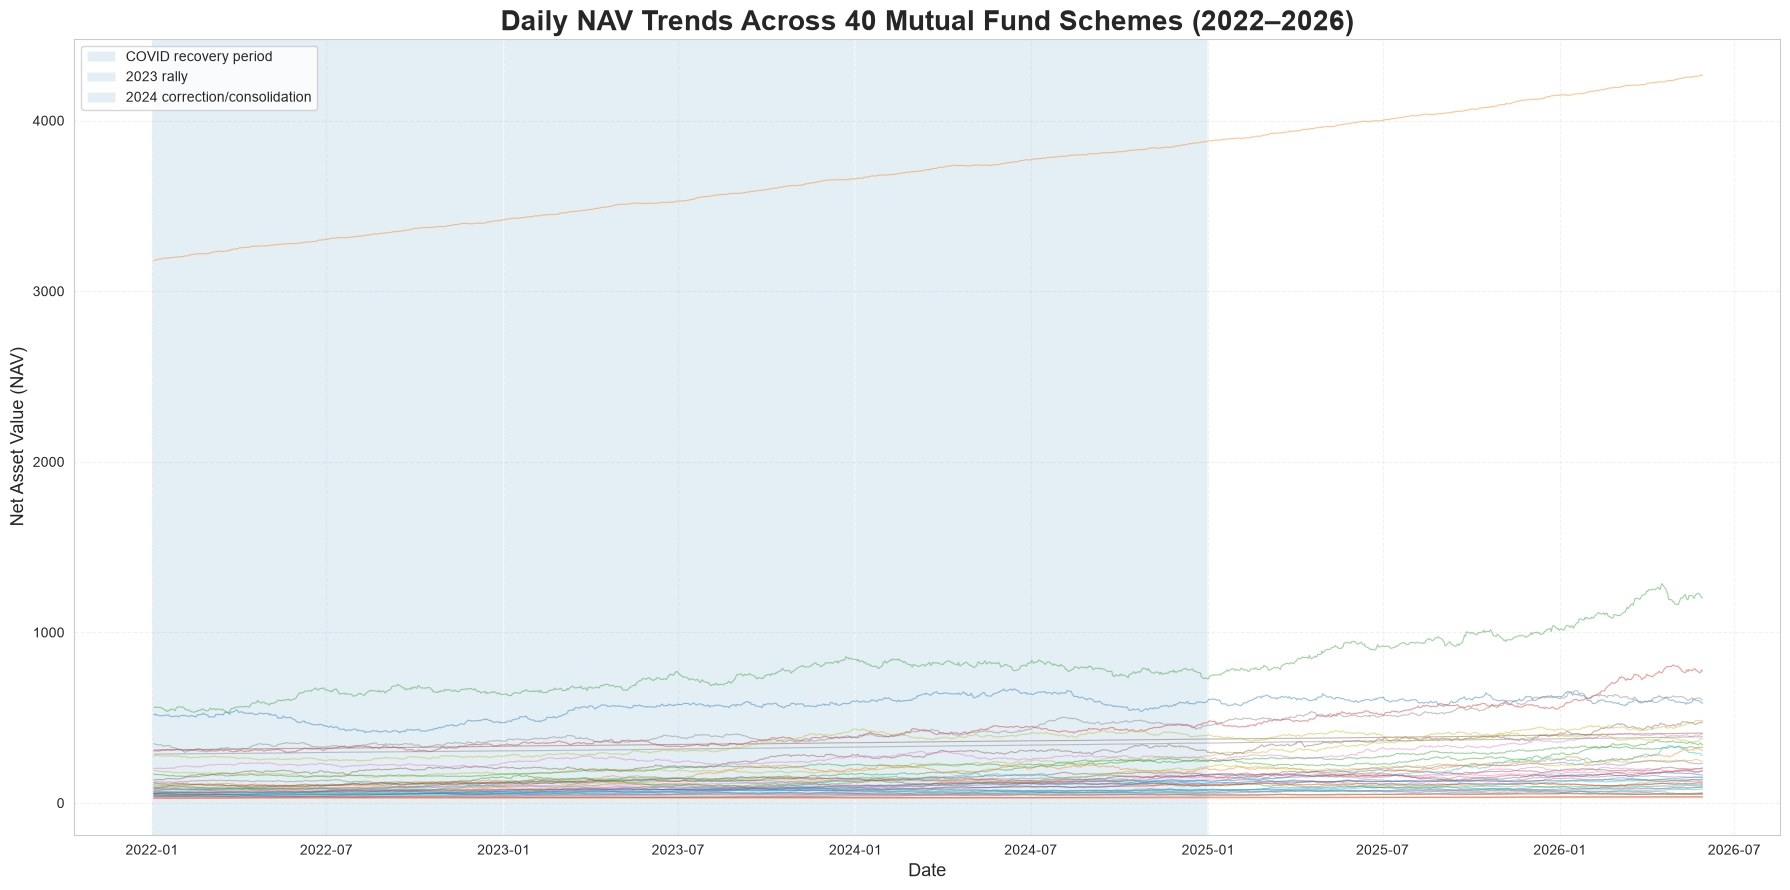

In [29]:
plt.figure(figsize=(18, 9))


for amfi_code, group in nav_df.groupby("amfi_code"):
    plt.plot(
        group["date"],
        group["nav"],
        linewidth=0.8,
        alpha=0.45
    )




plt.axvspan(
    pd.Timestamp("2022-01-01"),
    pd.Timestamp("2022-12-31"),
    alpha=0.12,
    label="COVID recovery period"
)


plt.axvspan(
    pd.Timestamp("2023-01-01"),
    pd.Timestamp("2023-12-31"),
    alpha=0.12,
    label="2023 rally"
)

plt.axvspan(
    pd.Timestamp("2024-01-01"),
    pd.Timestamp("2024-12-31"),
    alpha=0.12,
    label="2024 correction/consolidation"
)


plt.title(
    "Daily NAV Trends Across 40 Mutual Fund Schemes (2022–2026)",
    fontsize=20,
    fontweight="bold"
)

plt.xlabel("Date", fontsize=13)
plt.ylabel("Net Asset Value (NAV)", fontsize=13)

plt.grid(
    True,
    linestyle="--",
    alpha=0.25
)

plt.legend(
    loc="upper left",
    frameon=True
)

plt.tight_layout()
plt.show()

In [30]:


phase_data = nav_df.copy()

phase_data["phase"] = "Other"

phase_data.loc[
    (phase_data["date"] >= "2022-01-01") &
    (phase_data["date"] <= "2022-12-31"),
    "phase"
] = "COVID Recovery (2022)"

phase_data.loc[
    (phase_data["date"] >= "2023-01-01") &
    (phase_data["date"] <= "2023-12-31"),
    "phase"
] = "2023 Rally"

phase_data.loc[
    (phase_data["date"] >= "2024-01-01") &
    (phase_data["date"] <= "2024-12-31"),
    "phase"
] = "2024 Correction/Consolidation"

phase_data = phase_data[
    phase_data["phase"] != "Other"
]

phase_summary = (
    phase_data
    .groupby("phase")["nav"]
    .agg(["count", "mean", "min", "max"])
    .round(2)
)

phase_summary

,count,mean,min,max
phase,,,,
2023 Rally,10400,245.92,27.51,3658.77
2024 Correction/Consolidation,10480,276.09,27.88,3877.99
COVID Recovery (2022),10400,215.13,26.14,3417.70


In [31]:


scheme_volatility = (
    nav_df.groupby("amfi_code")["nav"]
    .agg(
        mean_nav="mean",
        std_nav="std",
        min_nav="min",
        max_nav="max"
    )
    .sort_values("std_nav", ascending=False)
)

scheme_volatility.head(10)

,mean_nav,std_nav,min_nav,max_nav
amfi_code,,,,
120844,3705.876331,303.025291,3180.6318,4268.5497
125497,797.454477,161.260356,529.6352,1286.0621
101206,435.975472,120.403930,297.0795,808.0982
149322,439.176645,94.000878,296.9505,658.5042
120505,283.999240,85.191901,133.1682,476.3696
102887,249.530563,83.908873,149.9155,419.3008
100033,190.825330,71.714049,93.5553,367.6979
120841,355.078750,65.730228,246.6585,484.6292
100016,566.191221,61.482668,411.1759,669.7236


In [32]:


scheme_volatility["cv_pct"] = (
    scheme_volatility["std_nav"] /
    scheme_volatility["mean_nav"]
) * 100

scheme_volatility = scheme_volatility.sort_values(
    "cv_pct",
    ascending=False
)

scheme_volatility.head(10)

,mean_nav,std_nav,min_nav,max_nav,cv_pct
amfi_code,,,,,
148567,136.480609,54.487473,70.2514,251.6557,39.923234
120843,97.822895,38.420676,44.8104,180.7074,39.275751
149324,148.214974,57.565798,73.6757,336.6937,38.839394
149323,151.492094,57.817232,72.9664,257.6666,38.165181
119094,121.444471,46.164296,61.5099,211.7678,38.012678
100033,190.825330,71.714049,93.5553,367.6979,37.580990
102887,249.530563,83.908873,149.9155,419.3008,33.626692
119551,78.847733,24.356424,50.0295,151.4373,30.890456
120504,99.940254,30.213618,59.4577,164.2321,30.231680


In [34]:

fund_df = pd.read_csv("../data/raw/01_fund_master.csv")

fund_df["amfi_code"] = fund_df["amfi_code"].astype(str)
scheme_volatility.index = scheme_volatility.index.astype(str)

volatility_named = scheme_volatility.reset_index()

volatility_named = volatility_named.rename(
    columns={"index": "amfi_code"}
)

volatility_named = volatility_named.merge(
    fund_df[
        ["amfi_code", "scheme_name", "fund_house", "category"]
    ],
    on="amfi_code",
    how="left"
)

volatility_named[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "category",
        "mean_nav",
        "std_nav",
        "cv_pct"
    ]
].head(10)

,amfi_code,scheme_name,fund_house,category,mean_nav,std_nav,cv_pct
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity,136.480609,54.487473,39.923234
1,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Equity,97.822895,38.420676,39.275751
2,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Equity,148.214974,57.565798,38.839394
3,149323,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Equity,151.492094,57.817232,38.165181
4,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Equity,121.444471,46.164296,38.012678
5,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,190.825330,71.714049,37.580990
6,102887,UTI Flexi Cap Fund - Regular - Growth,UTI Mutual Fund,Equity,249.530563,83.908873,33.626692
7,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,78.847733,24.356424,30.890456
8,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Equity,99.940254,30.213618,30.231680
9,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,283.999240,85.191901,29.997228


In [35]:
import os

print(os.listdir("../"))

['.git', '.gitignore', '.vscode', 'dashboard', 'data', 'data_dictionary.md', 'data_ingestion.py', 'excel', 'fetch_multiple_nav.py', 'live_nav_fetch.py', 'notebooks', 'README.md', 'reports', 'requirements.txt', 'sql']


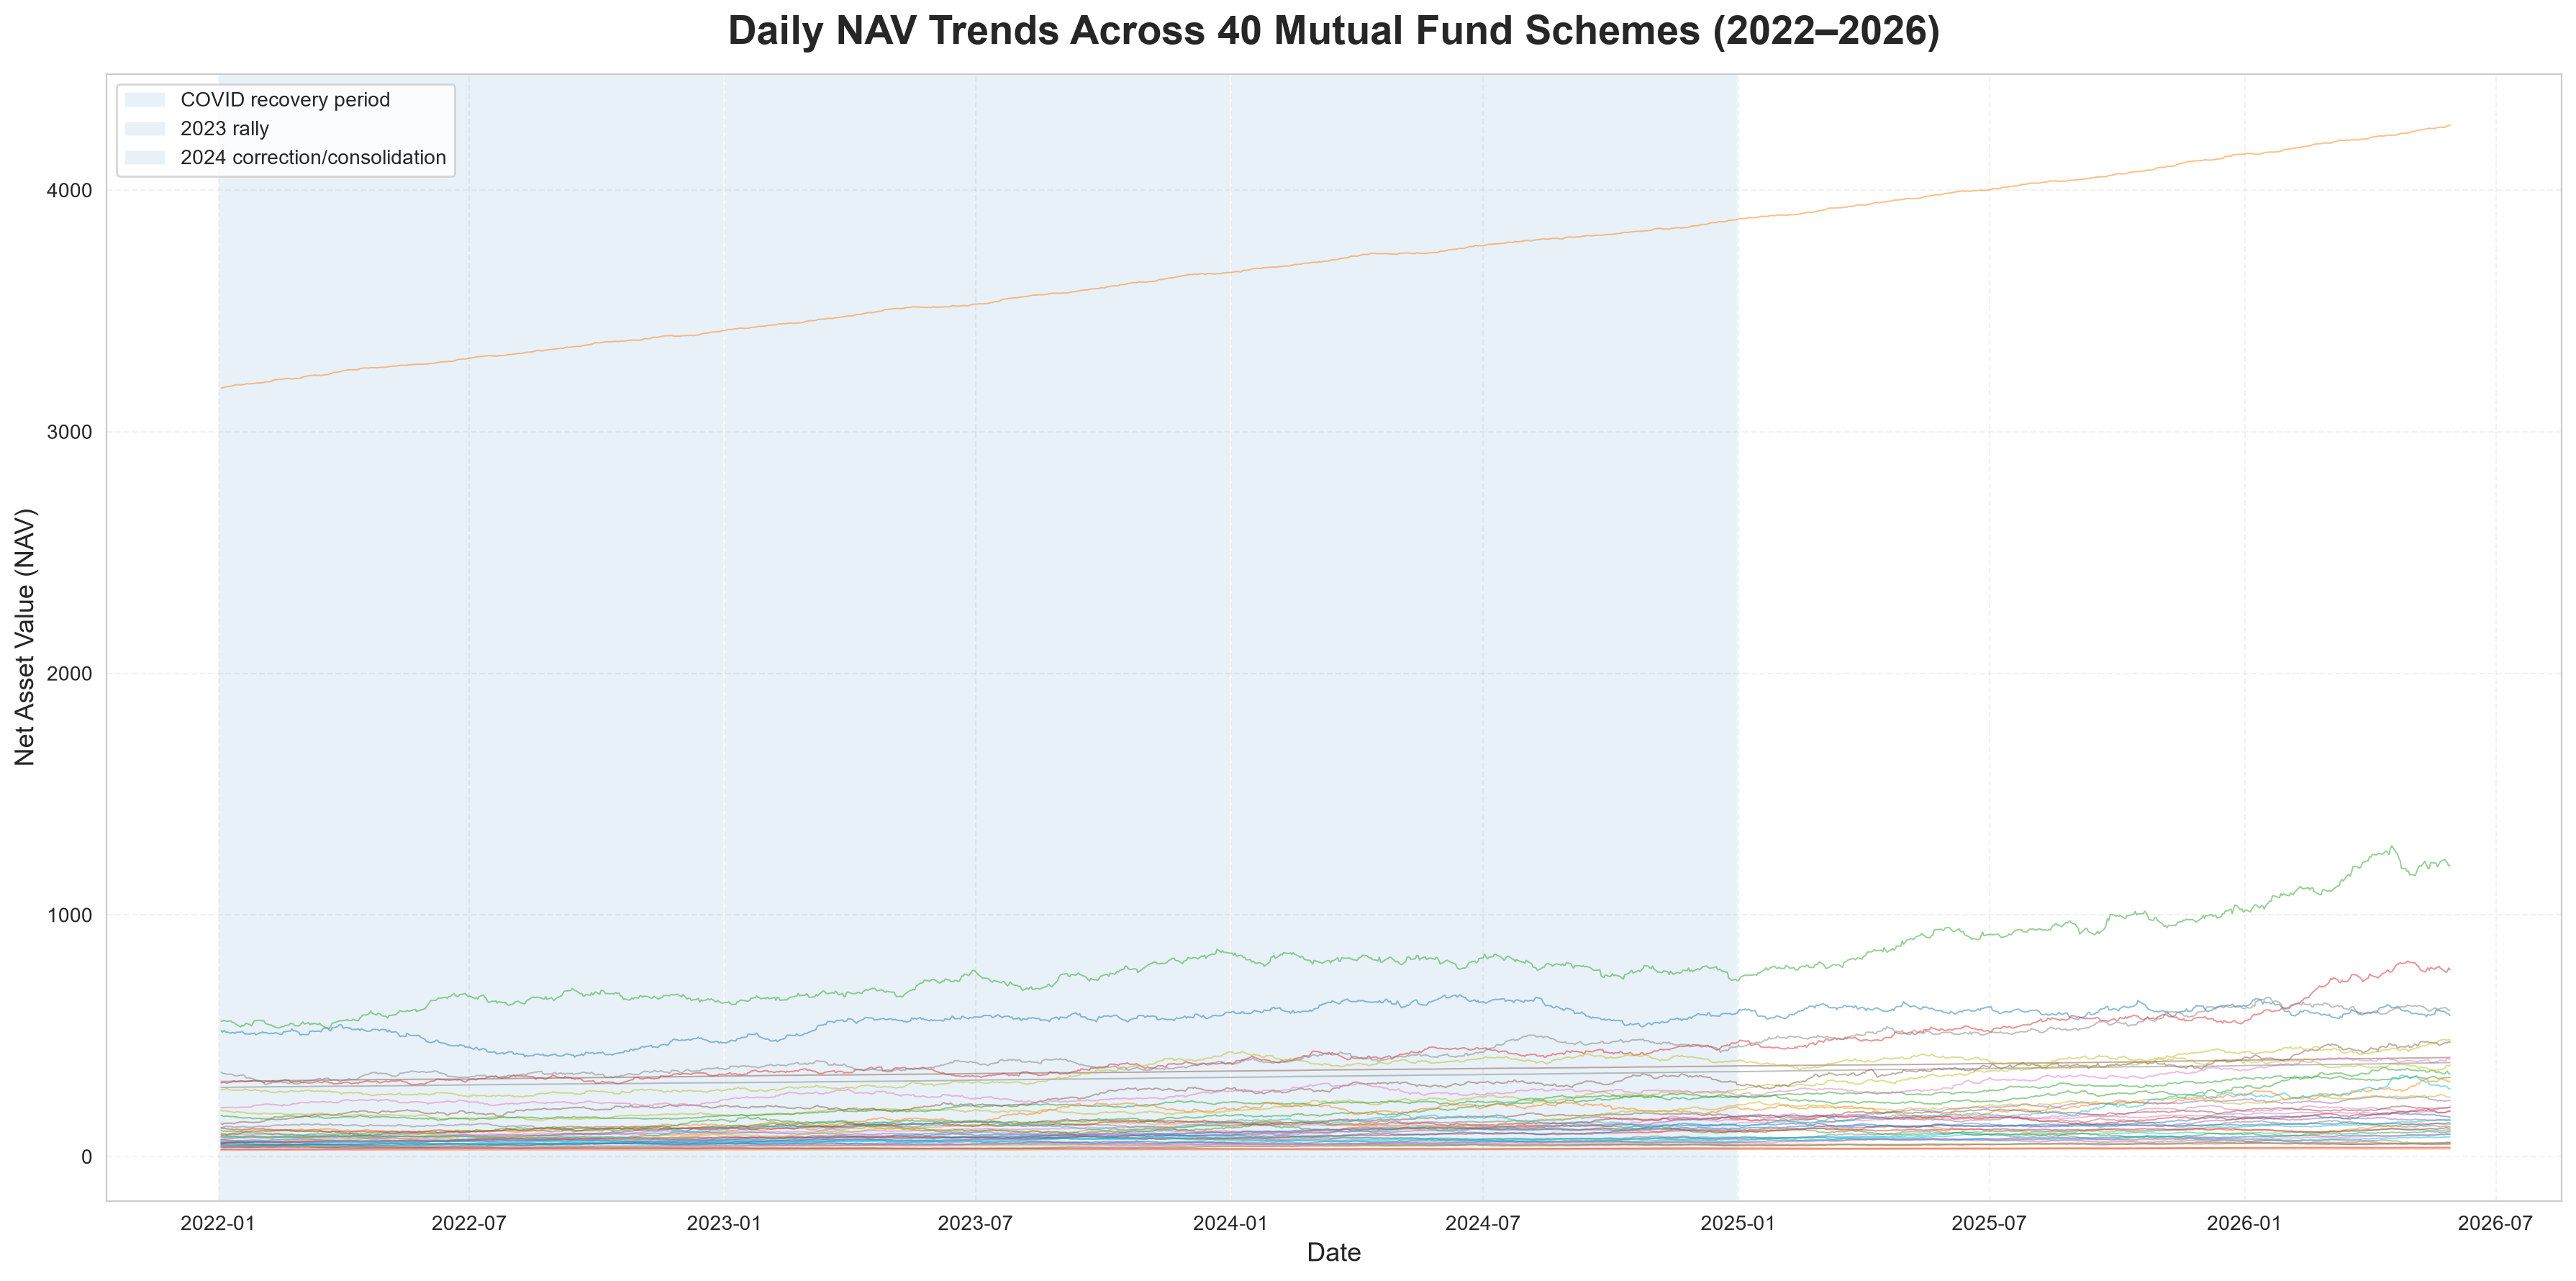

Task 1 deliverable saved successfully.
../reports/NAV_Trend_Analysis_Task1.png


In [36]:
import pandas as pd
import matplotlib.pyplot as plt

nav_df = pd.read_csv("../data/cleaned/clean_nav.csv")

nav_df["date"] = pd.to_datetime(nav_df["date"])
nav_df["nav"] = pd.to_numeric(nav_df["nav"], errors="coerce")

nav_df = nav_df.dropna(subset=["amfi_code", "date", "nav"])
nav_df = nav_df.sort_values(["amfi_code", "date"])

fig, ax = plt.subplots(figsize=(18, 9), dpi=200)


ax.axvspan(
    pd.Timestamp("2022-01-01"),
    pd.Timestamp("2022-12-31"),
    alpha=0.10,
    label="COVID recovery period"
)

ax.axvspan(
    pd.Timestamp("2023-01-01"),
    pd.Timestamp("2023-12-31"),
    alpha=0.10,
    label="2023 rally"
)

ax.axvspan(
    pd.Timestamp("2024-01-01"),
    pd.Timestamp("2024-12-31"),
    alpha=0.10,
    label="2024 correction/consolidation"
)


for amfi_code, group in nav_df.groupby("amfi_code"):
    ax.plot(
        group["date"],
        group["nav"],
        linewidth=0.7,
        alpha=0.50
    )


ax.set_title(
    "Daily NAV Trends Across 40 Mutual Fund Schemes (2022–2026)",
    fontsize=20,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Date",
    fontsize=13
)

ax.set_ylabel(
    "Net Asset Value (NAV)",
    fontsize=13
)


ax.grid(
    True,
    linestyle="--",
    alpha=0.25
)

ax.legend(
    loc="upper left",
    fontsize=10
)


plt.tight_layout()

plt.savefig(
    "../reports/NAV_Trend_Analysis_Task1.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Task 1 deliverable saved successfully.")
print("../reports/NAV_Trend_Analysis_Task1.png")

# Task 2: AUM Growth by Fund House

In [1]:


import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

aum_df = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

aum_df["date"] = pd.to_datetime(aum_df["date"])

aum_df.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [2]:

aum_df["year"] = aum_df["date"].dt.year

year_end_aum = aum_df[
    (aum_df["date"].dt.month == 12) &
    (aum_df["date"].dt.day == 31)
].copy()

year_end_aum = year_end_aum[
    year_end_aum["year"].between(2022, 2025)
]

year_end_aum[
    ["year", "fund_house", "aum_lakh_crore"]
].sort_values(
    ["year", "aum_lakh_crore"],
    ascending=[True, False]
)

,year,fund_house,aum_lakh_crore
60,2024,SBI Mutual Fund,11.14
61,2024,ICICI Prudential MF,8.74
62,2024,HDFC Mutual Fund,7.87
63,2024,Nippon India MF,5.70
64,2024,Kotak Mahindra MF,4.89
65,2024,Aditya Birla Sun Life MF,3.84
67,2024,UTI Mutual Fund,3.52
66,2024,Axis Mutual Fund,3.00
68,2024,Mirae Asset MF,2.10
69,2024,DSP Mutual Fund,1.88


In [4]:

aum_df["date"] = pd.to_datetime(aum_df["date"])

aum_df["year"] = aum_df["date"].dt.year

aum_yearly = (
    aum_df.sort_values("date")
          .groupby(["year", "fund_house"], as_index=False)
          .last()
)

aum_yearly = aum_yearly[["year", "fund_house", "aum_lakh_crore"]]

aum_yearly

,year,fund_house,aum_lakh_crore
0,2022,Aditya Birla Sun Life MF,2.85
1,2022,Axis Mutual Fund,2.40
2,2022,DSP Mutual Fund,1.12
3,2022,HDFC Mutual Fund,4.45
4,2022,ICICI Prudential MF,4.88
5,2022,Kotak Mahindra MF,2.72
6,2022,Mirae Asset MF,1.08
7,2022,Nippon India MF,2.78
8,2022,SBI Mutual Fund,6.30
9,2022,UTI Mutual Fund,2.32


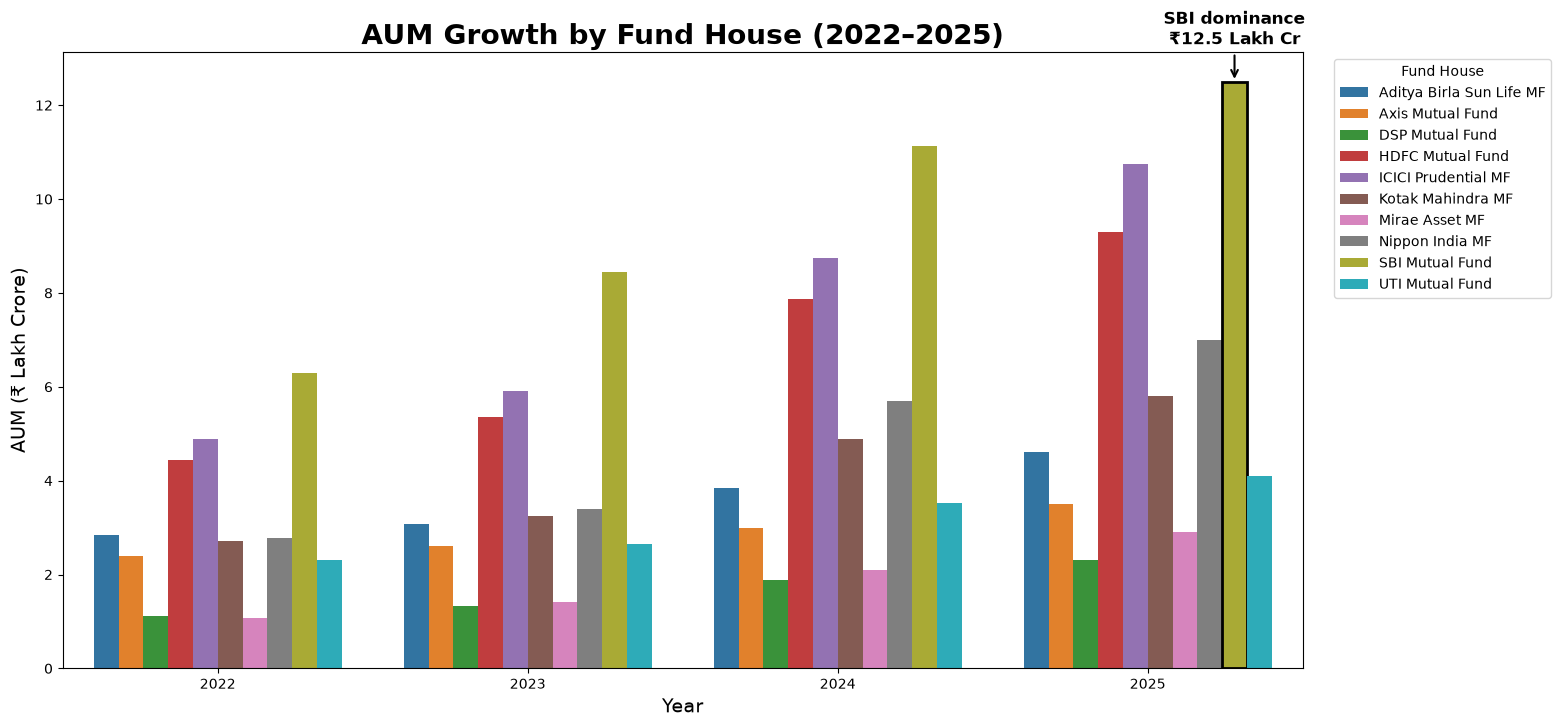

<Figure size 640x480 with 0 Axes>

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 8))

ax = sns.barplot(
    data=aum_yearly,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)


for bar in ax.patches:
    height = bar.get_height()

    
    if abs(height - 12.5) < 0.1:
        x = bar.get_x() + bar.get_width() / 2

        ax.annotate(
            "SBI dominance\n₹12.5 Lakh Cr",
            xy=(x, height),
            xytext=(x, height + 0.8),
            ha="center",
            fontsize=12,
            fontweight="bold",
            arrowprops=dict(
                arrowstyle="->",
                linewidth=1.5
            )
        )

        
        bar.set_edgecolor("black")
        bar.set_linewidth(2)

plt.title(
    "AUM Growth by Fund House (2022–2025)",
    fontsize=20,
    fontweight="bold"
)

plt.xlabel("Year", fontsize=14)
plt.ylabel("AUM (₹ Lakh Crore)", fontsize=14)

plt.legend(
    title="Fund House",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.savefig(
    "../reports/aum_growth_by_fund_house.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.tight_layout()
plt.show()

# task 3 SIP analysis

In [10]:
import pandas as pd

sip_df = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

sip_df.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [11]:
sip_df["month"] = pd.to_datetime(sip_df["month"])

print("Start Date:", sip_df["month"].min())
print("End Date:", sip_df["month"].max())
print("Total Months:", len(sip_df))

Start Date: 2022-01-01 00:00:00
End Date: 2025-12-01 00:00:00
Total Months: 48


In [12]:
dec_2025 = sip_df[sip_df["month"] == "2025-12"]

dec_2025

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
47,2025-12-01,31002,9.35,9.8,15.9,17.17


In [15]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=sip_df["month"],
        y=sip_df["sip_inflow_crore"],
        mode="lines+markers",
        name="Monthly SIP Inflow",
        line=dict(width=2),
        marker=dict(size=5)
    )
)


fig.add_annotation(
    x=pd.Timestamp("2025-12-01"),
    y=31002,
    text="₹31,002 Cr",
    showarrow=True,
    arrowhead=2,
    ax=-60,
    ay=-50
)

fig.update_layout(
    title="Monthly SIP Inflow Trend (2022–2025)",
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)",
    template="plotly_white",
    hovermode="x unified",
    width=1200,
    height=600
)

fig.show()